# The Active-Set Strategy

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ahmed-Bayoumy/MECH559/blob/DEV/L09/L09_active_set_method.ipynb)
### MECH 559 - Systems Optimization - L09

Companion notebook to the "Algorithms for nonlinearly constrained optimization" lecture. The active-set strategy keeps a *working set* $\mathcal A_k$ of inequality constraints treated as equalities, solves the resulting equality-constrained KKT system, then either **adds** a constraint that is violated or **drops** a constraint whose multiplier is negative - one constraint at a time - until every candidate constraint is satisfied and every active multiplier is non-negative.

## Learning objectives

By the end, students should be able to:

1. Solve the equality-constrained KKT system for a given working set $\mathcal A_k$ (a quadratic program with linear constraints, in closed form).
2. Apply the add rule (some candidate constraint is violated $\Rightarrow$ add the most-violated one) and the drop rule (some active multiplier is negative $\Rightarrow$ drop the most-negative one).
3. Trace both directions of the strategy: growing the working set from too few active constraints, and shrinking it from too many.
4. Cross-check the final KKT point against a general-purpose constrained solver.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

plt.rcParams.update({
    "font.size": 11,
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

COLORS = {"working": "#D1495B", "candidate": "#1D5FA8", "optimum": "#2A9D5C", "feasible": "#A8DADC"}
print(f"NumPy {np.__version__}, SciPy ok")

NumPy 2.5.0, SciPy ok


---
## 1. A generic equality-constrained QP solver

We work with quadratic objectives $f(x)=\tfrac12 x^\mathsf{T}Hx + c^\mathsf{T}x$ and linear inequality constraints $g_i(x) = a_i^\mathsf{T}x - b_i \le 0$, $i=1,\dots,m$. Given a working set $\mathcal A_k\subseteq\{1,\dots,m\}$, step 1 of the algorithm ("find a KKT point of the problem with the current working set") is exactly the linear KKT system

$$
\begin{bmatrix} H & A_{\mathcal A}^\mathsf{T} \\ A_{\mathcal A} & 0 \end{bmatrix}
\begin{bmatrix} x \\ \mu_{\mathcal A} \end{bmatrix}
=
\begin{bmatrix} -c \\ b_{\mathcal A} \end{bmatrix},
$$

where $A_{\mathcal A}$ stacks the rows $a_i^\mathsf{T}$ for $i\in\mathcal A_k$. We solve this directly (no iterative optimizer needed - it's linear algebra) and implement steps 2-4 exactly as in the slides.

In [3]:
def solve_equality_kkt(H, c, A, b, working_set):
    # Solve the KKT system for f = 0.5 x^T H x + c^T x  s.t.  a_i^T x = b_i, i in working_set.
    n = H.shape[0]
    idx = list(working_set)
    if not idx:
        x = np.linalg.solve(H, -c)
        return x, {}
    Aw = A[idx]
    bw = b[idx]
    m = len(idx)
    KKT = np.block([[H, Aw.T], [Aw, np.zeros((m, m))]])
    rhs = np.concatenate([-c, bw])
    sol = np.linalg.solve(KKT, rhs)
    x, mu = sol[:n], sol[n:]
    return x, dict(zip(idx, mu))


def active_set_method(H, c, A, b, working_set0, verbose=True):
    # Papalambros & Wilde active-set strategy (steps 1-4 of the slides).
    m = A.shape[0]
    working = set(working_set0)
    log = []
    for it in range(20):
        x, mu = solve_equality_kkt(H, c, A, b, working)
        g = A @ x - b
        candidates = [j for j in range(m) if j not in working]
        violated = [j for j in candidates if g[j] > 1e-9]
        negative_mu = [i for i in working if mu[i] < -1e-9]

        log.append({"iter": it, "x": x.copy(), "A": sorted(working), "mu": dict(mu),
                     "g": g.copy(), "violated": violated, "negative_mu": negative_mu})

        if not violated and not negative_mu:
            if verbose:
                print(f"iter {it}: KKT point x={np.round(x,4)}, A={sorted(working)} -- optimality "
                      f"(all candidates feasible, all active multipliers >= 0): EXIT")
            break
        if violated:
            j_add = violated[np.argmax(g[violated])]
            if verbose:
                print(f"iter {it}: x={np.round(x,4)}, A={sorted(working)} -- constraint {j_add} violated "
                      f"(g={g[j_add]:.3f} > 0) -> add it")
            working.add(j_add)
        elif negative_mu:
            i_drop = min(negative_mu, key=lambda i: mu[i])
            if verbose:
                print(f"iter {it}: x={np.round(x,4)}, A={sorted(working)} -- mu_{i_drop}={mu[i_drop]:.3f} < 0 "
                      f"-> drop it")
            working.remove(i_drop)
    return x, mu, log

---
## 2. Scenario A - growing the working set ("Active constraints")

$$
\min_{x_1,x_2}\; f(x) = (x_1-5)^2+(x_2-5)^2
\qquad\text{s.t.}\qquad
g_1(x)=x_1+x_2-4\le0,\quad g_2(x)=x_1-1\le0.
$$

The unconstrained minimizer $(5,5)$ violates both constraints. We deliberately start with an *incomplete* working set $\mathcal A_0=\{1\}$ (as if only $g_1$ had been detected as active) so the algorithm has to discover and add $g_2$ itself.

In [4]:
H = np.array([[2.0, 0.0], [0.0, 2.0]])
c = np.array([-10.0, -10.0])          # f = x^T H x/2 + c^T x + const, minimized at (5,5)
A = np.array([[1.0, 1.0], [1.0, 0.0]])
b = np.array([4.0, 1.0])

print("Scenario A: starting working set A0 = {1}\n")
xA, muA, logA = active_set_method(H, c, A, b, working_set0={0})
mu_rounded = {k: round(v, 4) for k, v in muA.items()}
print(f"\nFinal point: x* = {np.round(xA,4)}, multipliers = {mu_rounded}")

Scenario A: starting working set A0 = {1}

iter 0: x=[2. 2.], A=[0] -- constraint 1 violated (g=1.000 > 0) -> add it
iter 1: KKT point x=[1. 3.], A=[0, 1] -- optimality (all candidates feasible, all active multipliers >= 0): EXIT

Final point: x* = [1. 3.], multipliers = {0: np.float64(4.0), 1: np.float64(4.0)}


---
## 3. Scenario B - shrinking the working set ("Inactive constraints")

Same two constraints, but now the unconstrained minimizer of $f$ is the *origin* (feasible), so eventually every constraint should be dropped:

$$
\min_{x_1,x_2}\; f(x) = x_1^2+x_2^2
\qquad\text{s.t.}\qquad
g_1(x)=x_1+x_2-4\le0,\quad g_2(x)=x_1-1\le0.
$$

We deliberately start with an *over-complete* working set $\mathcal A_0=\{1,2\}$ (both constraints artificially forced active) to exercise the drop rule.

In [5]:
c_B = np.array([0.0, 0.0])           # f = x^T H x / 2, minimized at (0,0)

print("Scenario B: starting working set A0 = {1, 2}\n")
xB, muB, logB = active_set_method(H, c_B, A, b, working_set0={0, 1})
print(f"\nFinal point: x* = {np.round(xB,4)}, multipliers = {{}} (no active constraints)")

Scenario B: starting working set A0 = {1, 2}

iter 0: x=[1. 3.], A=[0, 1] -- mu_0=-6.000 < 0 -> drop it
iter 1: x=[1. 0.], A=[1] -- mu_1=-2.000 < 0 -> drop it
iter 2: KKT point x=[-0.  0.], A=[] -- optimality (all candidates feasible, all active multipliers >= 0): EXIT

Final point: x* = [-0.  0.], multipliers = {} (no active constraints)


---
## 4. Visualizing both paths

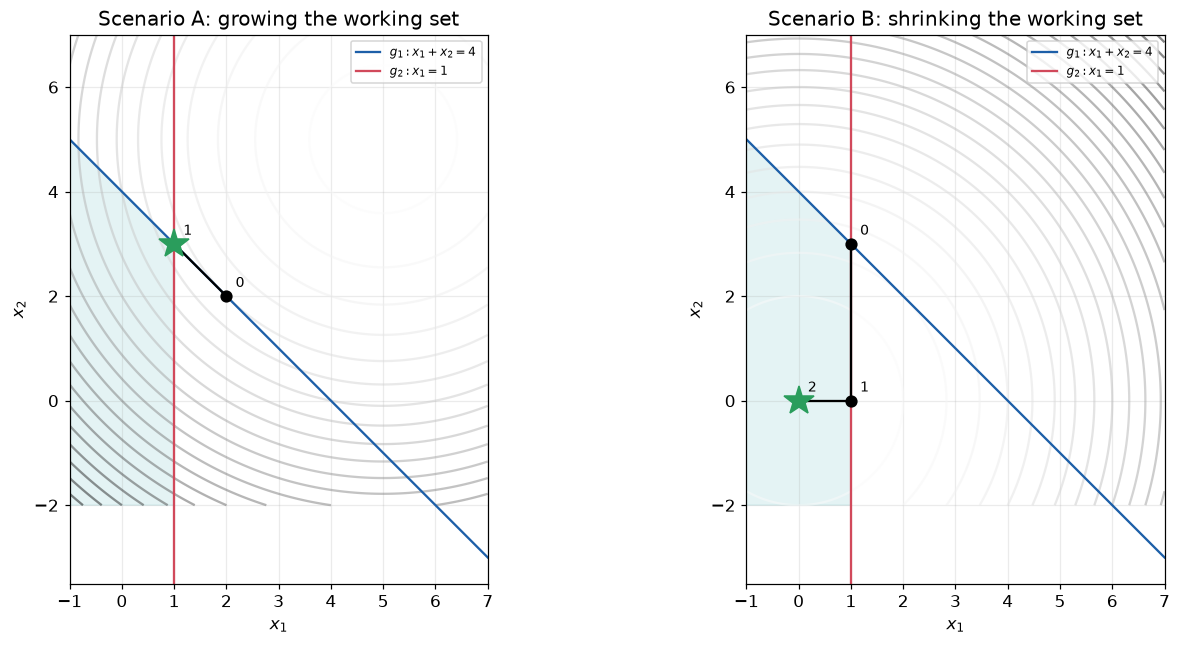

In [6]:
def plot_scenario(ax, c_vec, log, title):
    x1g, x2g = np.meshgrid(np.linspace(-1, 7, 300), np.linspace(-2, 7, 300))
    Fg = 0.5 * (H[0, 0] * x1g ** 2 + H[1, 1] * x2g ** 2) + c_vec[0] * x1g + c_vec[1] * x2g
    ax.contour(x1g, x2g, Fg, levels=25, cmap="Greys", alpha=0.5)

    xx = np.linspace(-1, 7, 10)
    ax.plot(xx, 4 - xx, color=COLORS["candidate"], lw=1.5, label=r"$g_1: x_1+x_2=4$")
    ax.axvline(1.0, color=COLORS["working"], lw=1.5, label=r"$g_2: x_1=1$")
    feasible = np.array([[1, 3], [-1, 5], [-1, -2], [1, -2]])
    ax.fill([1, -1, -1, 1], [3, 5, -2, -2], color=COLORS["feasible"], alpha=0.3, zorder=0)

    pts = np.array([entry["x"] for entry in log])
    ax.plot(pts[:, 0], pts[:, 1], "-o", color="black", ms=7)
    for i, entry in enumerate(log):
        ax.annotate(str(i), entry["x"], textcoords="offset points", xytext=(6, 6), fontsize=9)
    ax.plot(*pts[-1], "*", color=COLORS["optimum"], ms=20, zorder=5)
    ax.set(xlabel="$x_1$", ylabel="$x_2$", title=title, aspect="equal")
    ax.legend(fontsize=8, loc="upper right")

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
plot_scenario(axes[0], c, logA, "Scenario A: growing the working set")
plot_scenario(axes[1], c_B, logB, "Scenario B: shrinking the working set")
plt.tight_layout()
plt.show()

---
## 5. Cross-check against a general-purpose solver

In [7]:
def f_A(x):
    return (x[0] - 5.0) ** 2 + (x[1] - 5.0) ** 2

def f_B(x):
    return x[0] ** 2 + x[1] ** 2

cons = [{"type": "ineq", "fun": lambda x: 4.0 - x[0] - x[1]},
        {"type": "ineq", "fun": lambda x: 1.0 - x[0]}]

resA = minimize(f_A, x0=[5.0, 5.0], constraints=cons, method="SLSQP")
resB = minimize(f_B, x0=[0.5, 0.5], constraints=cons, method="SLSQP")

print("Scenario A -- active set:", np.round(xA, 4), " SLSQP:", np.round(resA.x, 4))
print("Scenario B -- active set:", np.round(xB, 4), " SLSQP:", np.round(resB.x, 4))
assert np.allclose(xA, resA.x, atol=1e-5)
assert np.allclose(xB, resB.x, atol=1e-5)
print("\nAgreement confirmed for both scenarios.")

Scenario A -- active set: [1. 3.]  SLSQP: [1. 3.]
Scenario B -- active set: [-0.  0.]  SLSQP: [-0. -0.]

Agreement confirmed for both scenarios.


---
## Takeaways

1. With a working set fixed, finding a KKT point is *linear algebra* (solve the bordered system once) - all the "intelligence" of the method is in deciding when to add or drop a constraint from that working set.
2. **Add rule:** if the KKT point of the current subproblem violates a candidate constraint, add the *most*-violated one and re-solve. This can only make the working set grow.
3. **Drop rule:** if the KKT point is feasible but some active multiplier is negative (i.e. removing that constraint would decrease $f$ further), drop the *most*-negative one and re-solve.
4. Only one constraint is added or dropped per iteration - this guards against cycling between the same two working sets.
5. Scenario A and B are mirror images of each other: one discovers that the working set is too small, the other that it is too large; both converge to the same kind of exit condition (all candidates feasible, all active multipliers $\ge0$).